## 회귀 분석으로 보는 심슨의 역설 

심슨의 역설을 보통은 회귀 분석으로 설명하지 않는다. 그런데 회귀 분석으로 보면 보다 명확하다. 

:::{ .column-margin }
데이터는 [여기](https://towardsdatascience.com/the-curious-case-of-simpsons-paradox-6f178548d7e8)서 갖고 왔다 

![](https://user-images.githubusercontent.com/39834789/86522451-84949f00-be38-11ea-9555-6409579f3b58.png)
:::

`culmen`은 새의 부리를 뜻한다. 옆 그림에서 보듯이 `length`는 부리의 앞으로 튀어나온 길이를, `depth`는 부리의 높이를 의미한다. 아래 데이터는 펭귄의 세 가지 종족, 성별 등을 별도로 기록하고 있다. 이제 심슨 역설의 전형적인 사례를 펭귄 부리의 길이와 높이를 통해 살펴보도록 하자. 

In [6]:
# Basic packages
import pandas as pd 
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
# Stats models 
import statsmodels.formula.api as sm
import statsmodels.stats.sandwich_covariance as sw
import statsmodels as statsmodels
from linearmodels import PanelOLS, FamaMacBeth
%matplotlib inline

csv_addr = "data/penguins_size.csv"
plt.style.use("fivethirtyeight")# for pretty graphs
df  = pd.read_csv('data/penguins_size.csv')
df.head();
#df.info();
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 334 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            334 non-null    object 
 1   island             334 non-null    object 
 2   culmen_length_mm   334 non-null    float64
 3   culmen_depth_mm    334 non-null    float64
 4   flipper_length_mm  334 non-null    float64
 5   body_mass_g        334 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 20.9+ KB


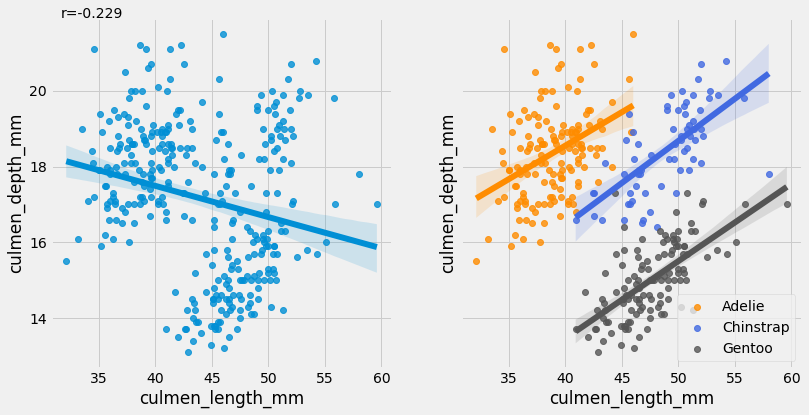

In [4]:

plt.rcParams['figure.figsize'] = [12, 6]
fig, (ax1, ax2) = plt.subplots(ncols=2, sharey=True)
sns.regplot(x = 'culmen_length_mm',y = 'culmen_depth_mm', data = df, ax=ax1)
r = stats.pearsonr(df['culmen_length_mm'], df['culmen_depth_mm'])[0]
ax1.text(.03, 1, 'r={:.3f}'.format(r), transform=ax1.transAxes)
colors = ['darkorange', 'royalblue', '#555555']
markers = ['.', '+', 'x']
#
for i, value in enumerate(df['species'].unique()):
    ax2 = sns.regplot(x="culmen_length_mm", y="culmen_depth_mm", ax=ax2,
                     color=colors[i],
                     #marker=markers[i],                      
                     data=df[df['species'] == value],
                     label=value)
ax2.legend(loc='best');

왼쪽 그림에서 보듯이 종족 구분 없이 펭귄 부리의 길이와 높이를 보면 서로 음의 상관성을 지니고 있는 듯 보인다. 그런데 이를 종족 별로 구별해서 살펴보면 오히려 길이와 높이는 양의 상관성을 지니고 있다. 

:::{ .column-margin }
![](https://user-images.githubusercontent.com/39834789/86522450-7f375480-be38-11ea-9437-9fd2a382aa7b.png)
:::

In [7]:
ols1 = sm.ols(formula="culmen_depth_mm ~ culmen_length_mm", data=df).fit(use_t=True)
ols2 = sm.ols(formula="culmen_depth_mm ~ species + culmen_length_mm", data=df).fit(use_t=True)
ols3 = sm.ols(formula="culmen_depth_mm ~ species * culmen_length_mm", data=df).fit(use_t=True)
#ols1.summary()
#ols2.summary()


from stargazer.stargazer import Stargazer
stargazer = Stargazer([ols1, ols2, ols3])
stargazer

회귀 분석에서 종족을 통제한 경우와 그렇지 않은 경우의 `culmen_length_mm`(부리의 길이)의 계수를 비교해보자. (1)은 종족을 통제하지 않은 회귀식으로 `culmen_length_mm`의 계수는 음수이다. 반면 종족을 통제한 (2)의 회귀식은 종족의 구분해 각 절편과 해당 종족 내의 부리의 길이와 높이의 관계를 계산해 이를 적절하게 가중 평균한 값이 `culmen_length_mm`의 계수가 된다. 회귀 테이블에서 보듯이 `culmen_length_mm`의 계수는 음수에서 양수로 바뀌어 있다. 

:::{ .column-margin }
나머지 계수의 의미는 기본이 되는 Adelie 종족을 기준으로 다른 두 개의 종족의 절편이 얼마나 떨어져 있는지를 보여준다. 회귀식을 적어보면 다음과 같다. 

식 (1) $y_i = \alpha_i + \beta x_i$

식 (2) $y_i = \alpha_i + \beta x_i + D_{1i} + D_{2i}$

- $y_i$: `culmen_depth_mm` 부리의 높이 
- $x_i$: `culmen_length_mm` 부리의 길이
- $D_{1i}$: 종족이 `Chinstrap`일 경우 1 이외는 0 
- $D_{2i}$: 종족이 `Gentoo`일 경우 1이외는 0

식 (3)은 $\beta_i$가 그룹별로 달라지는지 여부를 교호작용 항목을 통해 확인했다. (3)이 보여주듯이 그룹별로 $\beta_i$는 통계적으로 유의미한 차이가 없다. 
:::